In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Titanic-Dataset.csv")

## PART A: Conceptual Questions


### What is a Decision Tree Classifier and how does it make decisions?
##### A Decision Tree Classifier is a supervised ML algorithm that predicts classes by splitting data into branches based on feature conditions.
##### It asks sequential questions like “Age < 30?” or “Fare > 50?” until it reaches a final class prediction at a leaf node.

### What does a split criterion mean?

##### A split criterion is the rule used to decide the best feature and threshold for splitting data at each node.
##### Its goal is to create child groups that are as pure as possible (mostly one class).

### Difference between Gini Impurity and Entropy
#### Gini Impurity	                                                
##### Measures impurity using probability of wrong classification 
##### Faster to compute	      
#### Entropy
###### Measures impurity using information gain
###### Slightly slower due to logarithms

### Why do Decision Trees overfit?

##### Decision Trees overfit when they grow too deep and memorize noise and small patterns from training data.
##### Instead of learning general rules, they create very specific branches that fail on unseen data.

### What role does max_depth play?

##### max_depth limits how deep the tree can grow.
##### Smaller depth reduces overfitting but may underfit; larger depth increases complexity and variance.

### What is bias vs variance in classification?
##### Bias: Error from overly simple assumptions. High bias causes underfitting.
##### Variance: Error from sensitivity to training data. High variance causes overfitting.

##### A good model balances both.

## PART B: Data Exploration


#### Shape of the dataset


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

#### Target column

In [6]:
y = df["Survived"]

#### Feature columns

In [7]:
x= df.drop("Survived", axis=1)

### Check and report:


##### Missing values


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Data types


In [9]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## PART C: Data Preprocessing


#### Handle missing values.


In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [11]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

In [12]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

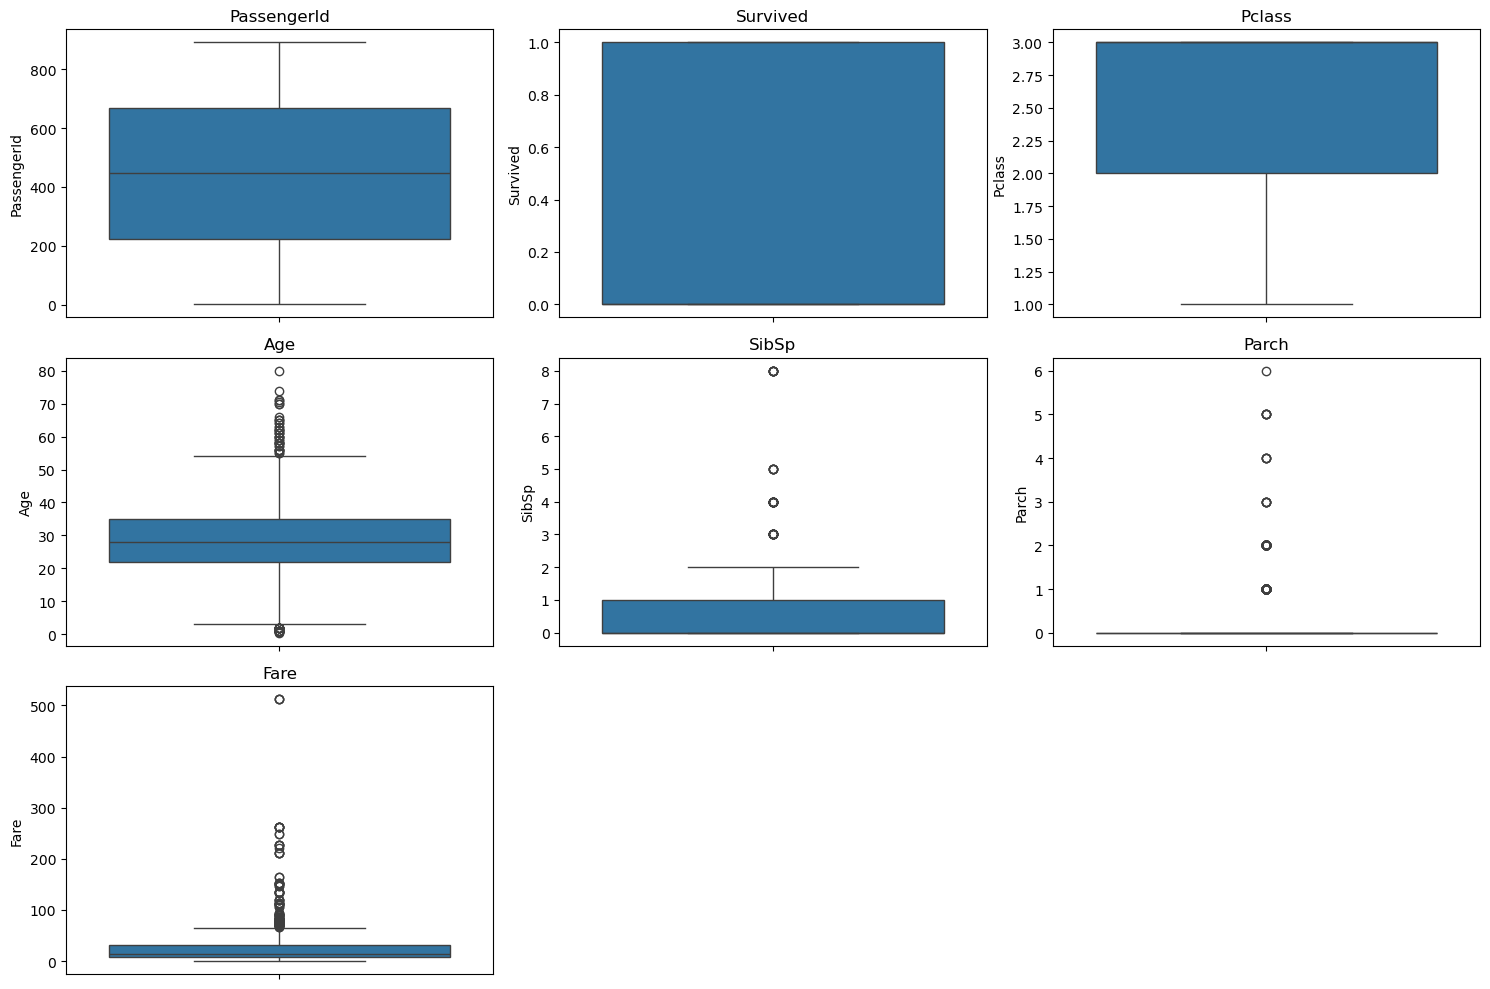

In [15]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

def cap_outliers(df, cols):
    df = df.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = df[col].clip(lower, upper)
    
    return df

df= cap_outliers(df, num_cols)

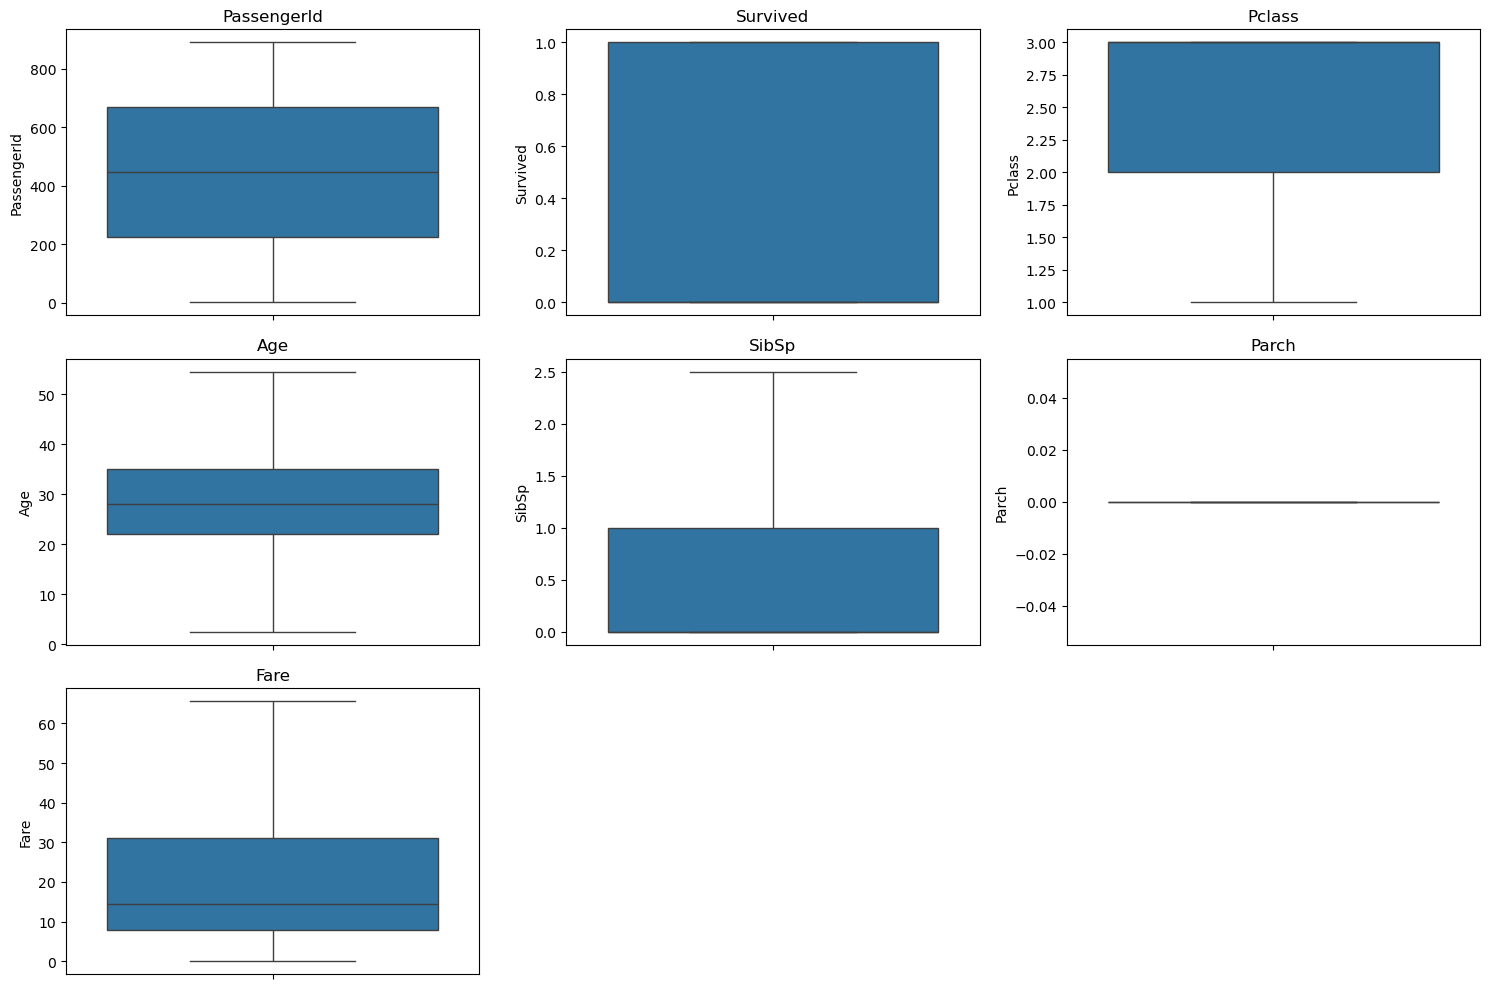

In [17]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

#### Encode categorical variables.


In [25]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
cat_cols=x.select_dtypes(['object']).columns
num_cols=x.select_dtypes(['float64','int64']).columns

ct = ColumnTransformer( transformers=[("oe",OrdinalEncoder(),cat_cols),
                                   ("sc",StandardScaler(),num_cols)])
x_transformed = ct.fit_transform(x)

x_transformed = pd.DataFrame(x_transformed)

print(x_transformed)

        0    1      2     3    4         5         6         7         8   \
0    108.0  1.0  523.0   NaN  2.0 -1.730108  0.827377 -0.530377  0.432793   
1    190.0  0.0  596.0  81.0  0.0 -1.726220 -1.566107  0.571831  0.432793   
2    353.0  0.0  669.0   NaN  2.0 -1.722332  0.827377 -0.254825 -0.474545   
3    272.0  0.0   49.0  55.0  2.0 -1.718444 -1.566107  0.365167  0.432793   
4     15.0  1.0  472.0   NaN  2.0 -1.714556  0.827377  0.365167 -0.474545   
..     ...  ...    ...   ...  ...       ...       ...       ...       ...   
886  548.0  1.0  101.0   NaN  2.0  1.714556 -0.369365 -0.185937 -0.474545   
887  303.0  0.0   14.0  30.0  2.0  1.718444 -1.566107 -0.737041 -0.474545   
888  413.0  0.0  675.0   NaN  2.0  1.722332  0.827377       NaN  0.432793   
889   81.0  1.0    8.0  60.0  0.0  1.726220 -1.566107 -0.254825 -0.474545   
890  220.0  1.0  466.0   NaN  1.0  1.730108  0.827377  0.158503 -0.474545   

           9         10  
0   -0.473674 -0.502445  
1   -0.473674  0.786845

#### Split the dataset:


In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## PART D: Model Building


In [32]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(criterion='gini',random_state=42)

In [35]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [36]:
x_train_transformed = preprocessor.fit_transform(x_train)

x_test_transformed = preprocessor.transform(x_test)

NameError: name 'preprocessor' is not defined

In [37]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Load data
df = pd.read_csv("Titanic-Dataset.csv")

# Drop unnecessary columns
df.drop(columns=["PassengerId","Name","Ticket","Cabin"], inplace=True)

# Features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64','float64']).columns

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Transform data
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

# Model
dtc = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

# Train model
dtc.fit(x_train_transformed, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
y_pred = dtc.predict(x_test_transformed)

print(y_pred)

[0 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 1
 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 1 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1
 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1]


## PART E: Model Evaluation


In [39]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [40]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:")
print(accuracy)

Accuracy Score:
0.776536312849162


In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[83 22]
 [18 56]]


In [42]:
# Classification Report
cr = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(cr)


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       105
           1       0.72      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



### Which class is predicted better?

##### Check the precision, recall, and F1-score in the classification report.

##### The class with:

##### higher precision
##### higher recall
##### higher F1-score

##### is predicted better.

### Is the model overfitting or underfitting?
##### If training accuracy is very high but test accuracy is lower → Overfitting
##### If both training and testing accuracy are low → Underfitting

### Why is accuracy alone not enough?

##### Accuracy only tells overall correct predictions.

##### A model can have high accuracy but still fail badly on one class

## PART F: Understanding Tree Depth (Manual Experiment)


In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2, 5, None]

for depth in depths:
    
    # Create model
    dtc = DecisionTreeClassifier(
        max_depth=depth,
        criterion='gini',
        random_state=42
    )
    
    # Train model
    dtc.fit(x_train_transformed, y_train)
    
    # Predictions
    y_train_pred = dtc.predict(x_train_transformed)
    y_test_pred = dtc.predict(x_test_transformed)
    
    # Accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    print(f"\nModel with max_depth = {depth}")
    print("Training Accuracy:", train_acc)
    print("Testing Accuracy :", test_acc)


Model with max_depth = 2
Training Accuracy: 0.8033707865168539
Testing Accuracy : 0.7653631284916201

Model with max_depth = 5
Training Accuracy: 0.851123595505618
Testing Accuracy : 0.7988826815642458

Model with max_depth = None
Training Accuracy: 0.9789325842696629
Testing Accuracy : 0.776536312849162


### What happens when the tree is very shallow?

##### A shallow tree learns only simple patterns from the data.
##### It usually misses important relationships, causing underfitting and lower accuracy on both training and testing data.

### What happens when the tree is very deep?

##### A deep tree keeps splitting until it memorizes training data, including noise.
##### This causes overfitting:

##### very high training accuracy
##### lower testing accuracy

##### The model becomes too specific and generalizes poorly.

In [47]:
# Best model
best_model = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=42
)

# Train
best_model.fit(x_train_transformed, y_train)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

### PART G: Tree Visualization


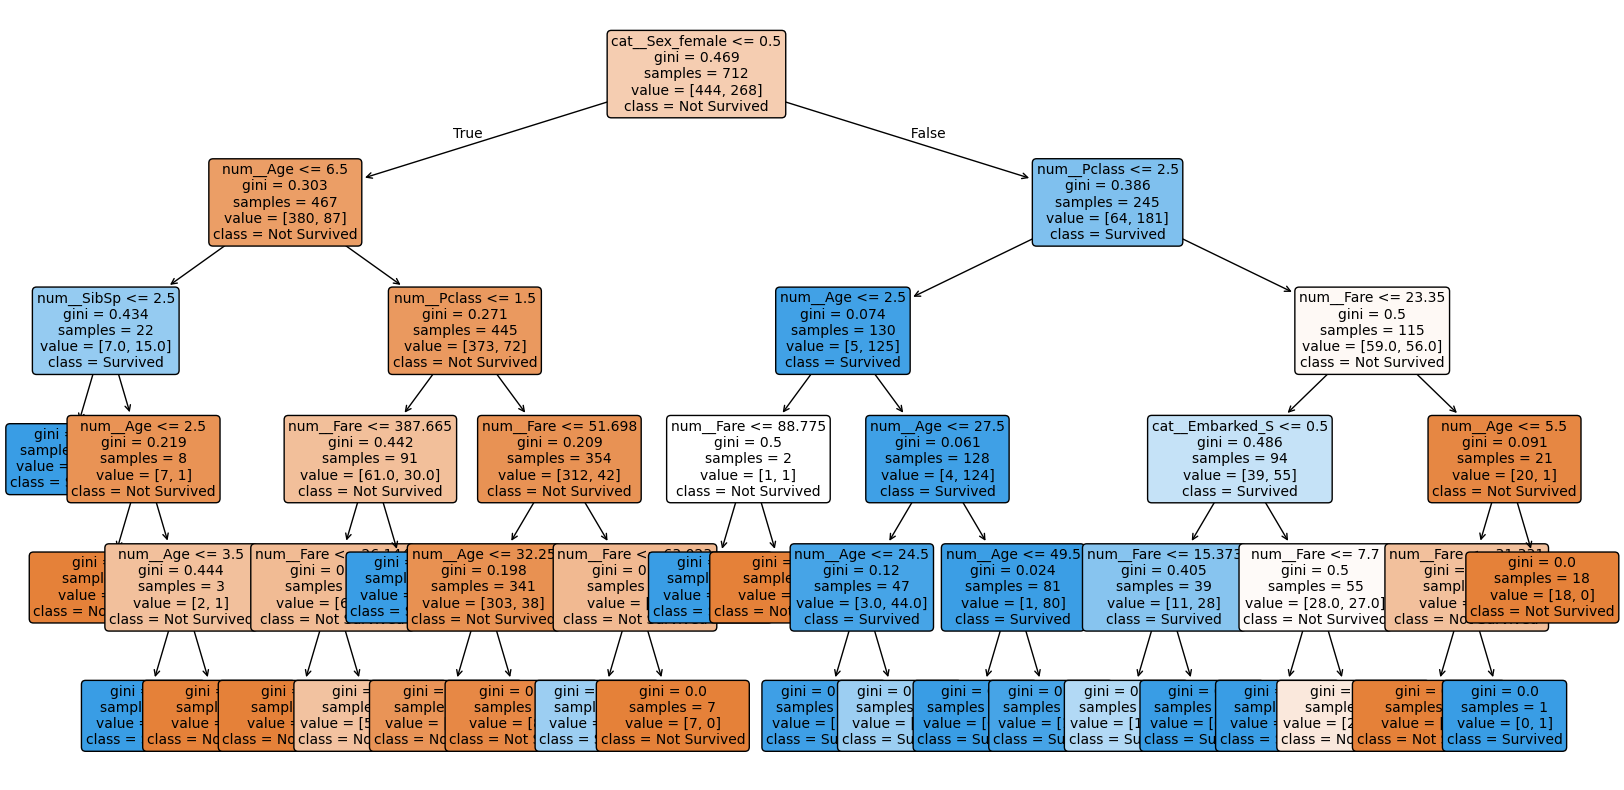

In [48]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=feature_names,
    class_names=['Not Survived', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

## PART H: Hyperparameter Comparison


In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Gini Model
gini_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

gini_model.fit(x_train_transformed, y_train)

gini_pred = gini_model.predict(x_test_transformed)

gini_acc = accuracy_score(y_test, gini_pred)

print("Gini Accuracy:", gini_acc)


# Entropy Model
entropy_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

entropy_model.fit(x_train_transformed, y_train)

entropy_pred = entropy_model.predict(x_test_transformed)

entropy_acc = accuracy_score(y_test, entropy_pred)

print("Entropy Accuracy:", entropy_acc)

Gini Accuracy: 0.7988826815642458
Entropy Accuracy: 0.8044692737430168


### Which performs better?


##### gini and entropy give very similar accuracy
##### sometimes one may be slightly better depending on the dataset


### Why does restricting leaf size reduce overfitting?

##### When min_samples_leaf is larger, the tree cannot create tiny leaf nodes for a few samples.

## PART I: Reflection Questions


### Why are Decision Trees suitable for survival prediction?

##### Decision Trees work well for survival prediction because they can handle:

##### categorical data (Sex, Embarked)
##### numerical data (Age, Fare)
##### nonlinear relationships

### What makes Decision Trees easy to interpret?

##### Decision Trees are easy to interpret because their decisions are visual and rule-based.

### Why are they widely used in Random Forest and Gradient Boosting?

##### A single Decision Tree is unstable and easily overfits.
##### Ensemble methods improve this weakness:

##### Random Forest combines many trees to reduce variance
##### Gradient Boosting builds trees sequentially to correct previous errors

## PART J: Conclusion

##### In this project, I learned how a Decision Tree Classifier works by splitting data into branches based on feature conditions to make predictions.  I also understood that Decision Trees are powerful and easy to interpret, but they can easily suffer from overfitting when the tree becomes too  deep and starts memorizing training data instead of learning general patterns.